# 07 - Greater Guayaquil: Manglar como Barrera contra Inundaciones
## Proyecto Boomerang - SpaceHACK 2026

Todo automatico, sin puntos manuales. Escala optimizada a 30m para velocidad.

Incluye **PASO 12** (triptico marea simulada) y **PASO 13** (capa **GMW 2020** para validar manglar vs umbrales S2). El dashboard Streamlit incluye **GMW** en mapas + motor lluvia/nivel mar (Open-Meteo) y pestaña *Simulacion Mareas*.

In [34]:
import ee
import geemap
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request
from datetime import datetime

ee.Initialize(project='august-tower-470819-s6')
os.makedirs('../exports', exist_ok=True)

def export_ee_image(image, vis_params, region, filename, dimensions=1024):
    url = image.getThumbURL({**vis_params, 'region': region, 'dimensions': dimensions, 'format': 'png'})
    urllib.request.urlretrieve(url, filename)
    print(f'  >> Exportado: {filename}')

def log(msg):
    print(f'[{datetime.now().strftime("%H:%M:%S")}] {msg}')

log('Setup completo')

[22:55:08] Setup completo


In [35]:
# === PASO 1: CARGAR DATOS ===
log('Cargando ROI y Sentinel-2...')

roi = ee.Geometry.Rectangle([-80.10, -2.30, -79.85, -1.98])

s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(roi)
    .filterDate('2023-06-01', '2024-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 40))
    .median().clip(roi))

log('Calculando indices espectrales...')
ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')
mndwi = s2.normalizedDifference(['B3', 'B11']).rename('MNDWI')
ndbi = s2.normalizedDifference(['B11', 'B8']).rename('NDBI')

log('Clasificando...')
classified = ee.Image(4)
classified = classified.where(ndvi.gt(0.5), 1)
classified = classified.where(ndbi.gt(0.0).And(ndvi.lt(0.3)), 2)
classified = classified.where(mndwi.gt(0.2).And(ndvi.lt(0.3)), 3)
classified = classified.clip(roi)

class_names = {1: 'Manglar/Vegetacion', 2: 'Zona Urbana', 3: 'Agua', 4: 'Suelo/Agricultura'}
log('PASO 1 COMPLETO - Datos cargados y clasificados')

[22:55:08] Cargando ROI y Sentinel-2...
[22:55:08] Calculando indices espectrales...
[22:55:08] Clasificando...
[22:55:08] PASO 1 COMPLETO - Datos cargados y clasificados


In [36]:
# === PASO 2: MAPA DE CLASIFICACION ===
log('Generando mapa...')

Map2 = geemap.Map(center=[-2.15, -79.95], zoom=11)
Map2.addLayer(s2, {'bands': ['B4','B3','B2'], 'max': 3000}, 'RGB', shown=False)
Map2.addLayer(classified, {'min': 1, 'max': 4, 'palette': ['228B22','FF4500','4169E1','DAA520']}, 'Uso de Suelo')
Map2.add_legend(title='Uso de Suelo', legend_dict={
    'Manglar/Vegetacion': '228B22', 'Zona Urbana': 'FF4500',
    'Agua': '4169E1', 'Suelo/Agricultura': 'DAA520'
})
log('PASO 2 COMPLETO')
Map2

[22:55:08] Generando mapa...
[22:55:09] PASO 2 COMPLETO


Map(center=[-2.15, -79.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [37]:
# === PASO 3: AREAS POR CLASE (escala 30m para velocidad) ===
log('Calculando areas por clase (esto tarda ~1 min)...')

areas = ee.Image.pixelArea().addBands(classified).reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=roi, scale=30, maxPixels=1e13
).getInfo()

log('Areas calculadas. Procesando resultados...')
class_areas = {}
for group in areas['groups']:
    class_areas[group['class']] = group['sum'] / 10000

total = sum(class_areas.values())

print('\n=== AREAS - Greater Guayaquil 2024 ===')
for cid in [1,2,3,4]:
    ha = class_areas.get(cid, 0)
    pct = ha / total * 100
    print(f'  {class_names[cid]}: {ha:,.0f} ha ({pct:.1f}%)')

manglar_pct = class_areas.get(1,0) / total * 100
urban_pct = class_areas.get(2,0) / total * 100

log('PASO 3 COMPLETO')

[22:55:09] Calculando areas por clase (esto tarda ~1 min)...
[22:55:10] Areas calculadas. Procesando resultados...

=== AREAS - Greater Guayaquil 2024 ===
  Manglar/Vegetacion: 42,494 ha (43.2%)
  Zona Urbana: 28,449 ha (28.9%)
  Agua: 7,110 ha (7.2%)
  Suelo/Agricultura: 20,349 ha (20.7%)
[22:55:10] PASO 3 COMPLETO


[22:55:10] Generando graficas...


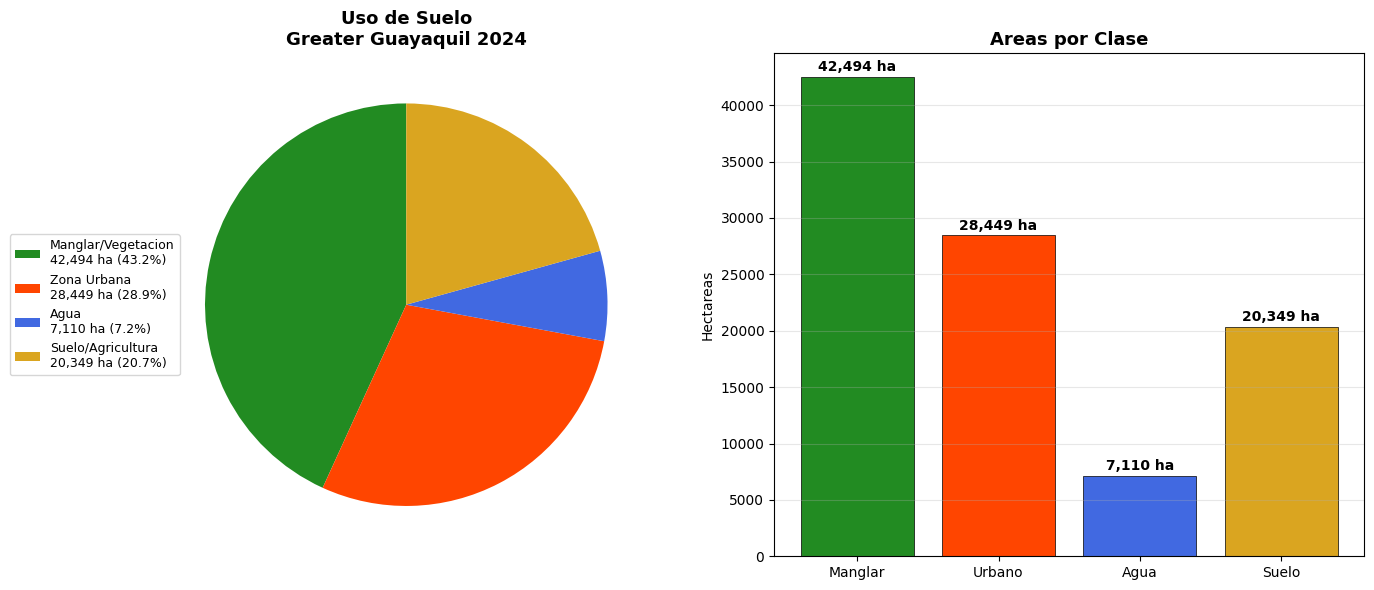

[22:55:10] PASO 4 COMPLETO - Exportado: gye_uso_suelo.png


In [38]:
# === PASO 4: GRAFICAS DE USO DE SUELO ===
log('Generando graficas...')

color_map = {1: '#228B22', 2: '#FF4500', 3: '#4169E1', 4: '#DAA520'}
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

labels = [f'{class_names[c]}\n{class_areas.get(c,0):,.0f} ha ({class_areas.get(c,0)/total*100:.1f}%)' for c in [1,2,3,4]]
sizes = [class_areas.get(c, 0) for c in [1,2,3,4]]
colors_pie = [color_map[c] for c in [1,2,3,4]]

ax1.pie(sizes, colors=colors_pie, startangle=90)
ax1.legend(labels, loc='center left', bbox_to_anchor=(-0.3, 0.5), fontsize=9)
ax1.set_title('Uso de Suelo\nGreater Guayaquil 2024', fontsize=13, fontweight='bold')

bars = ax2.bar(['Manglar', 'Urbano', 'Agua', 'Suelo'], sizes, color=colors_pie, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, sizes):
    ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+500, f'{val:,.0f} ha', ha='center', fontsize=10, fontweight='bold')
ax2.set_ylabel('Hectareas')
ax2.set_title('Areas por Clase', fontsize=13, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../exports/gye_uso_suelo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
log('PASO 4 COMPLETO - Exportado: gye_uso_suelo.png')

In [39]:
# === PASO 5: COSTA PROTEGIDA vs EXPUESTA (escala 30m) ===
log('Calculando zona costera 500m (esto tarda ~2 min)...')

water_mask = classified.eq(3)
coastal_buffer = water_mask.focal_max(radius=500, units='meters')
coastal_zone = coastal_buffer.And(water_mask.Not())
coastal_classified = classified.updateMask(coastal_zone)

log('Buffer calculado. Midiendo areas costeras...')
coastal_result = ee.Image.pixelArea().addBands(coastal_classified).reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=roi, scale=30, maxPixels=1e13
).getInfo()

log('Areas costeras calculadas.')
coastal_ha = {}
for group in coastal_result['groups']:
    coastal_ha[group['class']] = group['sum'] / 10000

total_coastal = sum(coastal_ha.values())
protected = coastal_ha.get(1, 0)
exposed_urban = coastal_ha.get(2, 0)
exposed_soil = coastal_ha.get(4, 0)
pct_protected = protected / total_coastal * 100 if total_coastal > 0 else 0
pct_exposed = (exposed_urban + exposed_soil) / total_coastal * 100 if total_coastal > 0 else 0

print(f'\n=== PROTECCION COSTERA (500m del agua) ===')
print(f'  PROTEGIDA por manglar: {pct_protected:.1f}% ({protected:,.0f} ha)')
print(f'  EXPUESTA (sin manglar): {pct_exposed:.1f}% ({exposed_urban+exposed_soil:,.0f} ha)')
print(f'    Urbano directo al agua: {exposed_urban:,.0f} ha')
print(f'    Suelo sin proteccion: {exposed_soil:,.0f} ha')

log('PASO 5 COMPLETO')

[22:55:10] Calculando zona costera 500m (esto tarda ~2 min)...
[22:55:10] Buffer calculado. Midiendo areas costeras...
[22:55:11] Areas costeras calculadas.

=== PROTECCION COSTERA (500m del agua) ===
  PROTEGIDA por manglar: 45.4% (9,740 ha)
  EXPUESTA (sin manglar): 54.6% (11,736 ha)
    Urbano directo al agua: 7,319 ha
    Suelo sin proteccion: 4,417 ha
[22:55:11] PASO 5 COMPLETO


[22:55:11] Generando graficas costeras...


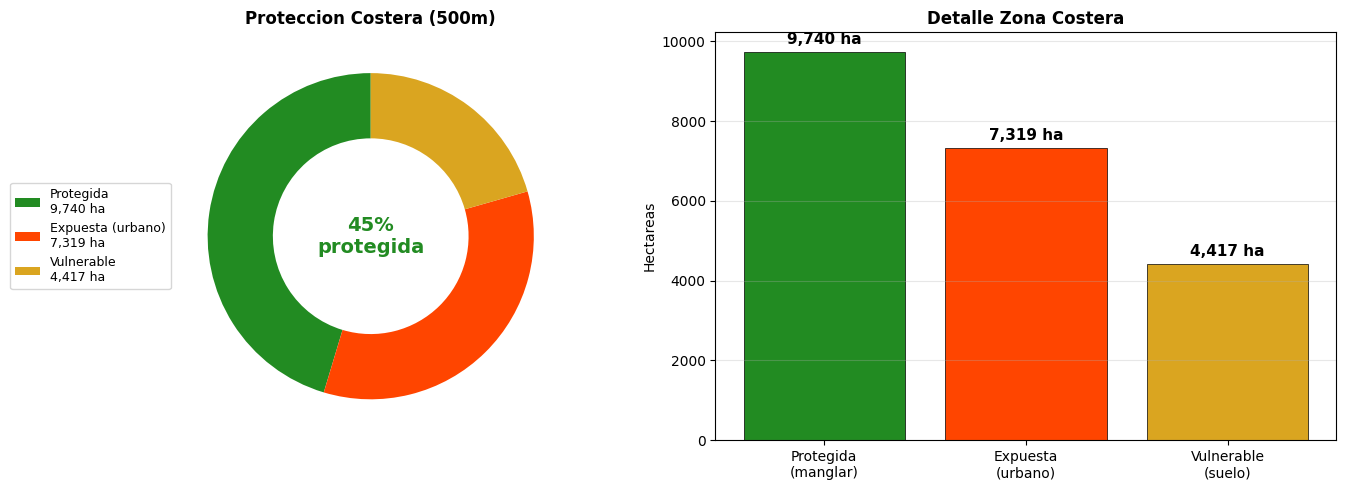

[22:55:11] PASO 6 COMPLETO - Exportado: gye_proteccion_costera.png


In [40]:
# === PASO 6: GRAFICAS DE PROTECCION COSTERA ===
log('Generando graficas costeras...')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

prot_sizes = [protected, exposed_urban, exposed_soil]
prot_colors = ['#228B22', '#FF4500', '#DAA520']
prot_labels = [f'Protegida\n{protected:,.0f} ha', f'Expuesta (urbano)\n{exposed_urban:,.0f} ha', f'Vulnerable\n{exposed_soil:,.0f} ha']

ax1.pie(prot_sizes, colors=prot_colors, startangle=90, wedgeprops=dict(width=0.4))
ax1.text(0, 0, f'{pct_protected:.0f}%\nprotegida', ha='center', va='center', fontsize=14, fontweight='bold', color='#228B22')
ax1.legend(prot_labels, loc='center left', bbox_to_anchor=(-0.4, 0.5), fontsize=9)
ax1.set_title('Proteccion Costera (500m)', fontsize=12, fontweight='bold')

bars = ax2.bar(['Protegida\n(manglar)', 'Expuesta\n(urbano)', 'Vulnerable\n(suelo)'], prot_sizes, color=prot_colors, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, prot_sizes):
    ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+200, f'{val:,.0f} ha', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Hectareas')
ax2.set_title('Detalle Zona Costera', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../exports/gye_proteccion_costera.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
log('PASO 6 COMPLETO - Exportado: gye_proteccion_costera.png')

In [41]:
# === PASO 7: MAPA COSTA PROTEGIDA vs EXPUESTA ===
log('Generando mapa de proteccion costera...')

Map3 = geemap.Map(center=[-2.15, -79.95], zoom=11)
Map3.addLayer(s2, {'bands': ['B4','B3','B2'], 'max': 3000}, 'RGB')
Map3.addLayer(coastal_classified.eq(1).selfMask(), {'palette': ['00FF00']}, 'PROTEGIDA (manglar)')
Map3.addLayer(coastal_classified.eq(2).selfMask(), {'palette': ['FF0000']}, 'EXPUESTA (urbano)')
Map3.addLayer(coastal_classified.eq(4).selfMask(), {'palette': ['FFA500']}, 'VULNERABLE (sin manglar)')
Map3.add_legend(title='Proteccion Costera', legend_dict={'Protegida': '00FF00', 'Expuesta (urbano)': 'FF0000', 'Vulnerable': 'FFA500'})
log('PASO 7 COMPLETO')
Map3

[22:55:11] Generando mapa de proteccion costera...
[22:55:14] PASO 7 COMPLETO


Map(center=[-2.15, -79.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [42]:
# === PASO 8: EXPANSION URBANA 2013-2024 ===
log('Procesando Landsat 2013 (esto tarda ~1 min)...')

def get_l8_masks(year):
    col = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
        .filterBounds(roi).filterDate(f'{year}-01-01', f'{year}-12-31')
        .filter(ee.Filter.lt('CLOUD_COVER', 50))
        .median().clip(roi))
    optical = col.select('SR_B.').multiply(0.0000275).add(-0.2)
    ndbi_l = optical.normalizedDifference(['SR_B6', 'SR_B5'])
    ndvi_l = optical.normalizedDifference(['SR_B5', 'SR_B4'])
    urban = ndbi_l.gt(0.0).And(ndvi_l.lt(0.3))
    manglar = ndvi_l.gt(0.5)
    return urban, manglar

urban_2013, manglar_2013 = get_l8_masks(2013)
log('2013 procesado. Procesando 2024...')
urban_2024, manglar_2024 = get_l8_masks(2024)
log('2024 procesado. Calculando cambios...')

new_urban = urban_2024.And(urban_2013.Not()).selfMask()
lost_manglar = manglar_2013.And(manglar_2024.Not()).selfMask()

log('Calculando areas de cambio...')
exp_area = new_urban.unmask(0).multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=roi, scale=30, maxPixels=1e13).getInfo()
lost_area = lost_manglar.unmask(0).multiply(ee.Image.pixelArea()).reduceRegion(
    reducer=ee.Reducer.sum(), geometry=roi, scale=30, maxPixels=1e13).getInfo()

expansion_ha = list(exp_area.values())[0] / 10000 if exp_area else 0
manglar_lost_ha = list(lost_area.values())[0] / 10000 if lost_area else 0

print(f'\n=== CAMBIO 2013-2024 ===')
print(f'  Nueva area urbana: +{expansion_ha:,.0f} ha')
print(f'  Manglar perdido:   -{manglar_lost_ha:,.0f} ha')
log('PASO 8 COMPLETO')

[22:55:14] Procesando Landsat 2013 (esto tarda ~1 min)...
[22:55:14] 2013 procesado. Procesando 2024...
[22:55:14] 2024 procesado. Calculando cambios...
[22:55:14] Calculando areas de cambio...

=== CAMBIO 2013-2024 ===
  Nueva area urbana: +8,446 ha
  Manglar perdido:   -6,208 ha
[22:55:15] PASO 8 COMPLETO


[22:55:15] Generando graficas de expansion...


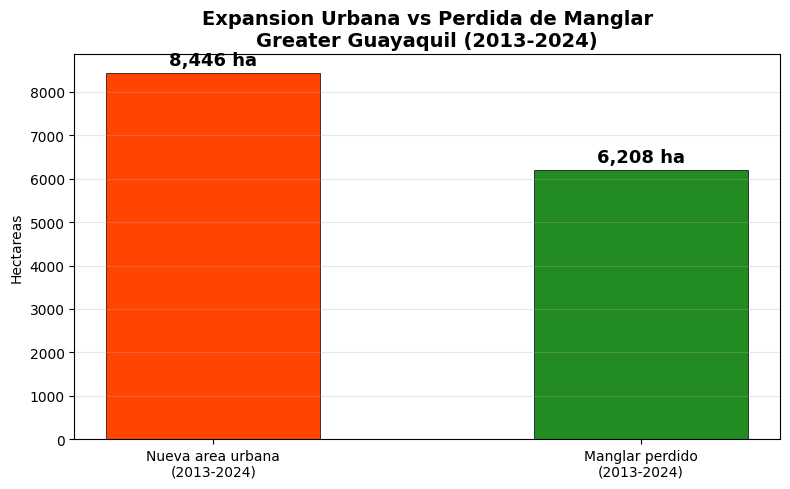

[22:55:17] PASO 9 COMPLETO


Map(center=[-2.15, -79.95], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright…

In [43]:
# === PASO 9: GRAFICAS Y MAPA DE EXPANSION ===
log('Generando graficas de expansion...')

fig, ax = plt.subplots(figsize=(8, 5))
vals = [expansion_ha, manglar_lost_ha]
bars = ax.bar(['Nueva area urbana\n(2013-2024)', 'Manglar perdido\n(2013-2024)'], vals,
              color=['#FF4500', '#228B22'], edgecolor='black', linewidth=0.5, width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+max(vals)*0.02,
            f'{val:,.0f} ha', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Hectareas')
ax.set_title('Expansion Urbana vs Perdida de Manglar\nGreater Guayaquil (2013-2024)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../exports/gye_expansion_vs_manglar.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Map4 = geemap.Map(center=[-2.15, -79.95], zoom=11)
Map4.addLayer(s2, {'bands': ['B4','B3','B2'], 'max': 3000}, 'RGB 2024')
Map4.addLayer(urban_2013.selfMask(), {'palette': ['FFA500']}, 'Urbano 2013')
Map4.addLayer(new_urban, {'palette': ['FF0000']}, 'Expansion 2013-2024')
Map4.addLayer(lost_manglar, {'palette': ['800080']}, 'Manglar perdido')
Map4.add_legend(title='Cambio', legend_dict={'Urbano 2013': 'FFA500', 'Expansion nueva': 'FF0000', 'Manglar perdido': '800080'})
log('PASO 9 COMPLETO')
Map4

In [44]:
# === PASO 10: SALUD DEL MANGLAR + EXPORTS ===
log('Calculando NDVI del manglar...')

ndvi_manglar = ndvi.updateMask(classified.eq(1))
ndvi_stats = ndvi_manglar.reduceRegion(
    reducer=ee.Reducer.mean().combine(ee.Reducer.min(), sharedInputs=True)
        .combine(ee.Reducer.max(), sharedInputs=True),
    geometry=roi, scale=30, maxPixels=1e13
).getInfo()

ndvi_mean = ndvi_stats.get('NDVI_mean', 0)
print(f'\n=== SALUD DEL MANGLAR ===')
print(f'  NDVI medio: {ndvi_mean:.4f}')
print(f'  NDVI max:   {ndvi_stats.get("NDVI_max", 0):.4f}')
print(f'  NDVI min:   {ndvi_stats.get("NDVI_min", 0):.4f}')
if ndvi_mean > 0.7: print('  Estado: SALUDABLE')
elif ndvi_mean > 0.5: print('  Estado: MODERADO')
else: print('  Estado: DEGRADADO')

log('Exportando imagenes satelitales...')
export_ee_image(s2, {'bands': ['B4','B3','B2'], 'min': 0, 'max': 3000}, roi, '../exports/gye_rgb_2024.png')
export_ee_image(classified, {'min': 1, 'max': 4, 'palette': ['228B22','FF4500','4169E1','DAA520']}, roi, '../exports/gye_clasificacion_2024.png')
export_ee_image(ndvi, {'min': -0.1, 'max': 0.8, 'palette': ['red','yellow','green','darkgreen']}, roi, '../exports/gye_ndvi_2024.png')
log('PASO 10 COMPLETO')

[22:55:17] Calculando NDVI del manglar...

=== SALUD DEL MANGLAR ===
  NDVI medio: 0.6808
  NDVI max:   0.9608
  NDVI min:   0.5001
  Estado: MODERADO
[22:55:18] Exportando imagenes satelitales...
  >> Exportado: ../exports/gye_rgb_2024.png
  >> Exportado: ../exports/gye_clasificacion_2024.png
  >> Exportado: ../exports/gye_ndvi_2024.png
[22:56:02] PASO 10 COMPLETO


[22:56:03] Generando panel de metricas...


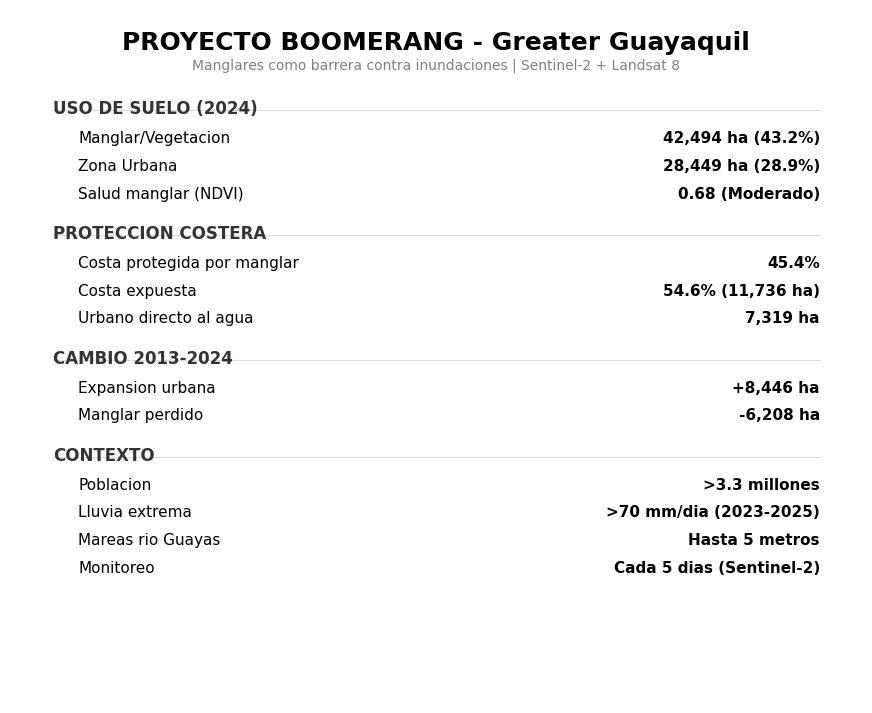

[22:56:03] PASO 11 COMPLETO - Exportado: gye_metricas.png


In [45]:
# === PASO 11: PANEL DE METRICAS ===
log('Generando panel de metricas...')

fig, ax = plt.subplots(figsize=(11, 9))
ax.axis('off')
ax.text(0.5, 0.97, 'PROYECTO BOOMERANG - Greater Guayaquil', fontsize=18, fontweight='bold', ha='center', va='top', transform=ax.transAxes)
ax.text(0.5, 0.93, 'Manglares como barrera contra inundaciones | Sentinel-2 + Landsat 8', fontsize=10, color='gray', ha='center', va='top', transform=ax.transAxes)

metrics = [
    ('USO DE SUELO (2024)', '', True),
    ('Manglar/Vegetacion', f'{class_areas.get(1,0):,.0f} ha ({manglar_pct:.1f}%)', False),
    ('Zona Urbana', f'{class_areas.get(2,0):,.0f} ha ({urban_pct:.1f}%)', False),
    ('Salud manglar (NDVI)', f'{ndvi_mean:.2f} ({"Sano" if ndvi_mean>0.7 else "Moderado" if ndvi_mean>0.5 else "Degradado"})', False),
    ('', '', False),
    ('PROTECCION COSTERA', '', True),
    ('Costa protegida por manglar', f'{pct_protected:.1f}%', False),
    ('Costa expuesta', f'{pct_exposed:.1f}% ({exposed_urban+exposed_soil:,.0f} ha)', False),
    ('Urbano directo al agua', f'{exposed_urban:,.0f} ha', False),
    ('', '', False),
    ('CAMBIO 2013-2024', '', True),
    ('Expansion urbana', f'+{expansion_ha:,.0f} ha', False),
    ('Manglar perdido', f'-{manglar_lost_ha:,.0f} ha', False),
    ('', '', False),
    ('CONTEXTO', '', True),
    ('Poblacion', '>3.3 millones', False),
    ('Lluvia extrema', '>70 mm/dia (2023-2025)', False),
    ('Mareas rio Guayas', 'Hasta 5 metros', False),
    ('Monitoreo', 'Cada 5 dias (Sentinel-2)', False),
]

y = 0.87
for label, value, is_header in metrics:
    if is_header:
        ax.text(0.05, y, label, fontsize=12, fontweight='bold', color='#333', transform=ax.transAxes, va='top')
        ax.plot([0.05, 0.95], [y-0.015, y-0.015], transform=ax.transAxes, color='#ccc', linewidth=0.5)
        y -= 0.045
    elif label == '': y -= 0.015
    else:
        ax.text(0.08, y, label, fontsize=11, transform=ax.transAxes, va='top')
        ax.text(0.95, y, value, fontsize=11, fontweight='bold', transform=ax.transAxes, va='top', ha='right')
        y -= 0.04

plt.savefig('../exports/gye_metricas.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
log('PASO 11 COMPLETO - Exportado: gye_metricas.png')

## PASO 12: Simulación de mareas (proxy de inundación)

Expansion morfológica desde la máscara de **agua** (clase 3): a mayor nivel simulado, más suelo urbano o descubierto queda bajo la franja azul **si no hay manglar en ~280 m** (misma lógica que el dashboard). No sustituye un modelo hidráulico con DEM; comunica el vínculo costa–riesgo para el pitch.

[23:37:57] Simulando niveles de marea (buffer desde agua clasificada)...
[23:37:57] Descargando RGB base (512 px) para composicion...


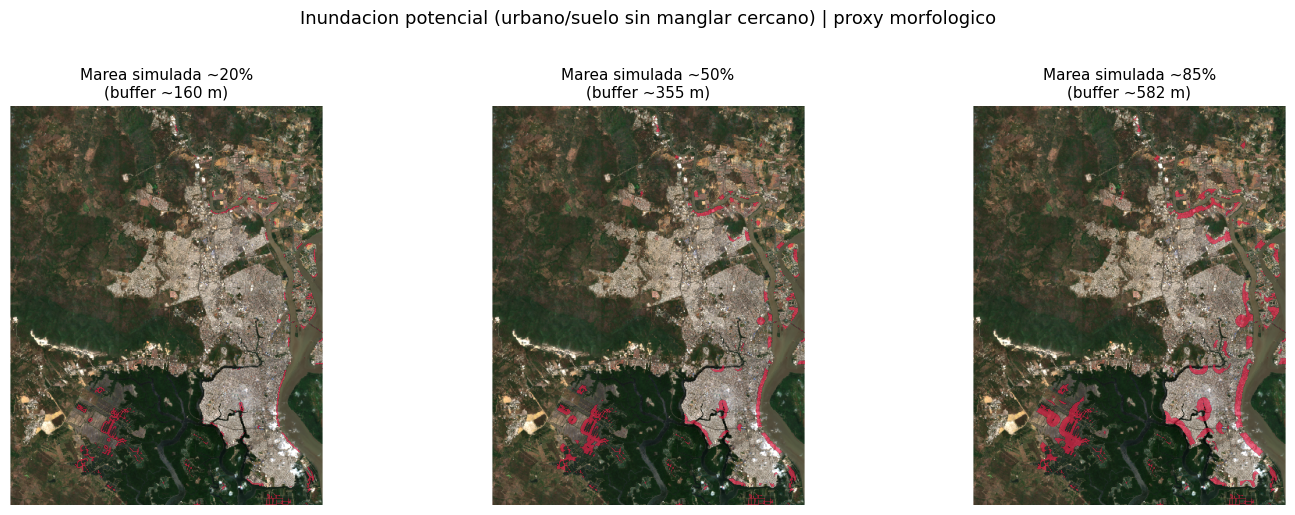

[23:38:25] PASO 12 COMPLETO - Interactivo: streamlit dashboard (pestana Simulacion Mareas)


In [47]:
# === PASO 12: SIMULACION MAREA - INUNDACION PROGRESIVA ===
log('Simulando niveles de marea (buffer desde agua clasificada)...')

water = classified.eq(3)
levels = [20, 50, 85]

log('Descargando RGB base (512 px) para composicion...')
rgb_url = s2.getThumbURL({
    'bands': ['B4', 'B3', 'B2'], 'min': 0, 'max': 3000,
    'region': roi, 'dimensions': 512, 'format': 'png'
})
urllib.request.urlretrieve(rgb_url, '../exports/gye_rgb_thumb_marea.png')
rgb = plt.imread('../exports/gye_rgb_thumb_marea.png')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, tide_pct in zip(axes, levels):
    buffer_m = int(30 + (tide_pct / 100.0) * 650)
    expanded = water.focal_max(radius=buffer_m, units='meters')
    mang_near = classified.eq(1).focal_max(radius=280, units='meters')
    urban_exp = expanded.And(classified.eq(2)).And(mang_near.Not())
    suelo_exp = expanded.And(classified.eq(4)).And(mang_near.Not())
    flood = urban_exp.Or(suelo_exp).selfMask()
    url = flood.getThumbURL({
        'min': 0, 'max': 1, 'palette': ['000000', 'DC143C'],
        'region': roi, 'dimensions': 512, 'format': 'png'
    })
    fname = f'../exports/gye_inundacion_proxy_{tide_pct}.png'
    urllib.request.urlretrieve(url, fname)
    flood_im = plt.imread(fname)
    ax.imshow(rgb)
    ax.imshow(flood_im, alpha=0.65)
    ax.set_title(f'Marea simulada ~{tide_pct}%\n(buffer ~{buffer_m} m)', fontsize=11)
    ax.axis('off')

fig.suptitle(
    'Inundacion potencial (urbano/suelo sin manglar cercano) | proxy morfologico',
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig('../exports/gye_marea_triptico.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
log('PASO 12 COMPLETO - Interactivo: streamlit dashboard (pestana Simulacion Mareas)')

## PASO 13: Validación con Global Mangrove Watch (GMW 2020)

Misma ROI. Capa de referencia **GMW** (Sentinel baseline ~10 m, `projects/sat-io/.../GMW_MNG_2020`) superpuesta al RGB. Compara con la clase «manglar» del PASO 1 (umbrales S2). Cita: Bunting et al., 2022; CC BY 4.0.

In [ ]:
# === PASO 13: GMW 2020 (validación externa) ===
log('Cargando GMW 2020 v4 sobre ROI...')

gmw_ic = ee.ImageCollection('projects/sat-io/open-datasets/GMW/annual-extent/GMW_MNG_2020').filterBounds(roi)
gmw_mang = gmw_ic.mosaic().clip(roi).eq(1).selfMask()

MapG = geemap.Map(center=[-2.15, -79.95], zoom=11)
MapG.addLayer(s2, {'bands': ['B4', 'B3', 'B2'], 'max': 3000}, 'S2 RGB')
MapG.addLayer(classified, {'min': 1, 'max': 4, 'palette': ['228B22', 'FF4500', '4169E1', 'DAA520']}, 'Clasificacion S2', shown=False)
MapG.addLayer(gmw_mang, {'palette': ['00FF88']}, 'GMW 2020 manglar')
MapG.add_legend(title='Referencia', legend_dict={'GMW 2020 manglar': '00FF88'})
log('PASO 13 COMPLETO — contrastar franjas con capa Proteccion costera')
MapG

In [46]:
# === RESUMEN FINAL ===
print('\n' + '='*55)
print('  GREATER GUAYAQUIL - RESUMEN FINAL')
print('='*55)
print(f'  Manglar: {class_areas.get(1,0):,.0f} ha ({manglar_pct:.1f}%)')
print(f'  Urbano: {class_areas.get(2,0):,.0f} ha ({urban_pct:.1f}%)')
print(f'  Costa protegida: {pct_protected:.1f}%')
print(f'  Costa expuesta: {pct_exposed:.1f}%')
print(f'  Expansion urbana (11 anios): +{expansion_ha:,.0f} ha')
print(f'  Manglar perdido (11 anios): -{manglar_lost_ha:,.0f} ha')
print(f'  NDVI manglar: {ndvi_mean:.2f}')
print('='*55)

print('\n=== IMAGENES GENERADAS ===')
for f in sorted(os.listdir('../exports')):
    if f.startswith('gye_'):
        size = os.path.getsize(f'../exports/{f}') / 1024
        print(f'  {f} ({size:.1f} KB)')

log('NOTEBOOK 07 TERMINADO')


  GREATER GUAYAQUIL - RESUMEN FINAL
  Manglar: 42,494 ha (43.2%)
  Urbano: 28,449 ha (28.9%)
  Costa protegida: 45.4%
  Costa expuesta: 54.6%
  Expansion urbana (11 anios): +8,446 ha
  Manglar perdido (11 anios): -6,208 ha
  NDVI manglar: 0.68

=== IMAGENES GENERADAS ===
  gye_clasificacion_2024.png (175.2 KB)
  gye_expansion_vs_manglar.png (48.4 KB)
  gye_metricas.png (113.2 KB)
  gye_ndvi_2024.png (1157.7 KB)
  gye_proteccion_costera.png (78.7 KB)
  gye_rgb_2024.png (2306.0 KB)
  gye_uso_suelo.png (95.4 KB)
[22:56:03] NOTEBOOK 07 TERMINADO
